#### Name: Sutton Ursillo

# PHYS 230 Lab Assignment 15

### Wednesday, April 1, 2026: Chapter 8.2-8.3
- Multivariable differential equations
- Second-order differential equations 

In [2]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a second-order ordinary differential equation for a simple harmonic oscillator. The standard equation is given as: 

$$\frac{d^2x}{dt^2}= -\omega^2 x $$

The general solution to this differential equation is: 

$$x(t) = c_1 \cos \omega t + c_2 \sin \omega t $$

where $c_1$ and $c_2$ can be found from initial conditions. 

For this problem, we will analyze the case of $\omega = 1$ in the range of $t=0$ to $t=50$. The initial conditions are $x=1$ and $dx/dt = 0$. 

*Problem adapted from Exercise 8.6 in the textbook*

### Part 1: Solving the second-order differential equation 

Let's solve for $x$ as a function of time. Do this in the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. 
*Double-check with the professor before moving on.*

$\frac{dx}{dt}= v$

$\frac{dv}{dt} = -w^2x$

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1. 

In [97]:
def f(r,t):

    x = r[0]
    v = r[1]

    #define the diff eqn

    fx = v
    fv = -omega**2 * x

    #return vector array of functions

    return np.array([fx,fv], float)


#### Step 3: Write a function `RK4_multi(r,t,h,f)` - like you did in the last lab - that you can use to solve any two simultaneous single-order differential equations.  

In [112]:
def RK4_multi(r,t_points,h,f):
    xpts = np.zeros(len(t_points))
    vpts = np.zeros(len(t_points))


    #adding what we made in class and adapting it


    for i in range(len(t_points)):
        xpts[i] = r[0]
        vpts[i] = r[1]

        k1 = h * f(r, t_points[i])
        k2 = h * f(r+0.5*k1, t_points[i]+0.5*h)
        k3 =  h * f(r+0.5*k2, t_points[i]+0.5*h)
        k4 =  h * f(r+k3, t_points[i]*h)

        r+= (k1+2*k2+2*k3+k4)/6

    return xpts, vpts


#### Step 4: Define any constants and arrays necessary for the problem and solve for $x$ and $dx/dt$ as a function of time. 

In [113]:
#defining the time values and constants
#adjusting anything that needs to be fixed
t_start = 0.0
t_end = 50.0
N_steps = 1000
h = (t_end-t_start)/N_steps
t_points = np.arange(t_start,t_end+h,h)
omega = 1.0
fx = 0.0
x = 1.0
r = np.array([1,0], float)
xpts = np.zeros(len(t_points))
vpts = np.zeros(len(t_points))

#### Step 5: Make a plot the position $x$ vs. time. Does this agree with what you expected (add a markdown cell explaining this)? 

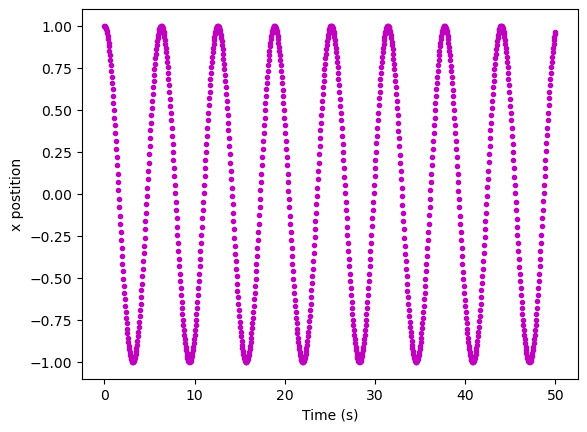

In [114]:
#making a plot of x vs time

x_pos, v_pos = RK4_multi(r,t_points,h,f)

plt.plot(t_points, x_pos, ".m")
plt.xlabel("Time (s)")
plt.ylabel("x postition")
plt.show()

From the general solution I assumed this would be some sort of oscillatory motion. The graph that I created confirms this as the x position oscillates between 3 and -3.

#### Step 6: Now graph $dx/dt$ vs. $x$ instead. This is called a *phase space* plot. Interpret the result (do an internet search to understand phase space plots if need be, but your explanations must be in your own words). 

If you would like to make your graph square, you can use: 
`plt.figure(figsize=(#,#))` replacing the #'s with whatever equal dimensions you want. 

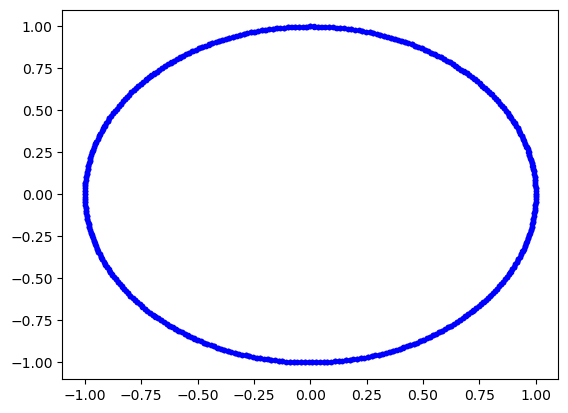

In [ ]:
#making the phase space plot
plt.plot(v_pos,x_pos, ".b")
plt.show()

The phase space plot that was created has an eliptical shape to it. This means that the motion of this system is controlled by a simple harmonic oscillator. It shows that the system is stable with sinusoidal motion and constant energy. 

### Part 2: Variations

Test what happens to your solution when we change some parameters. 

#### Step 1: Increase the amplitude of oscillators by making the initial position larger. Reanalyze the results and plot $x$ vs. $t$ again. What can you say about the oscillations? In particular, comment on the period of oscillations - what do we expect to happen to the period when the amplitude is increased?  

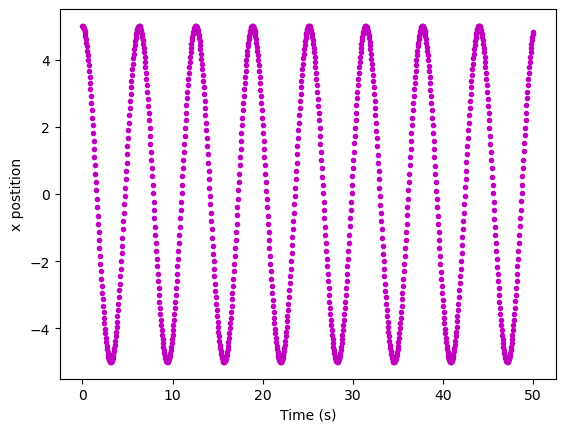

In [117]:
#increasing the amplitude


def f(r,t):

    x = r[0]
    v = r[1]

    #define the diff eqn

    fx = v
    fv = -omega**2 * x

    #return vector array of functions

    return np.array([fx,fv], float)


t_start = 0.0
t_end = 50.0
N_steps = 1000
h = (t_end-t_start)/N_steps
t_points = np.arange(t_start,t_end+h,h)
omega = 1.0
fx = 0.0
x = 1.0
r = np.array([5,0], float)
xpts = np.zeros(len(t_points))
vpts = np.zeros(len(t_points))



x_pos, v_pos = RK4_multi(r,t_points,h,f)

plt.plot(t_points, x_pos, ".m")
plt.xlabel("Time (s)")
plt.ylabel("x postition")
plt.show()




Compared to the first graph that was made this figure has an increased amplitude (which we coded). The period is the same as we only increased the amplitude. The amplitude corresponds to how much energy is in the system and not the frequency or period. So changing the amplitude has no effect on the period. 

#### Step 2: Using the original amplitude, change the initial conditions to be $x = 0$ and $dx/dt = 1$. Analyze the results and plot position vs. time again. What do you notice about the oscillations compared to the previous step and the original in Part 1?

(You may find it helpful to plot the original results from Part 1 simultaneously on the same graph for comparison)

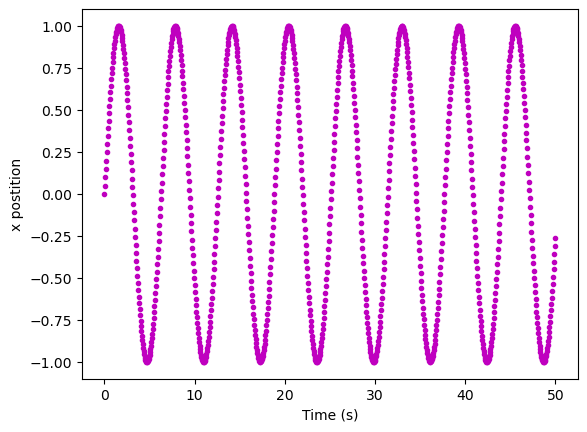

In [118]:
#increasing the amplitude

def f(r,t):

    x = r[0]
    v = r[1]

    #define the diff eqn

    fx = v
    fv = -omega**2 * x

    #return vector array of functions

    return np.array([fx,fv], float)


t_start = 0.0
t_end = 50.0
N_steps = 1000
h = (t_end-t_start)/N_steps
t_points = np.arange(t_start,t_end+h,h)
omega = 1.0
v = 1.0
x = 0.0
r = np.array([0,1], float)
xpts = np.zeros(len(t_points))
vpts = np.zeros(len(t_points))


x_pos, v_pos = RK4_multi(r,t_points,h,f)

plt.plot(t_points, x_pos, ".m")
plt.xlabel("Time (s)")
plt.ylabel("x postition")
plt.show()

Now the oscillation starts at 0 and it does not get as many full oscillations as the other graphs. 

### Part 3: Anharmonic Oscilator 

Let's now analyze the motion of an anharmonic oscillator described by the equations
$$ \frac{d^2x}{dt} = -\omega^2 x^3 $$
Again, analyze the case of $\omega = 1$ in the range of $t=0$ to $t=30$. The initial conditions are $x=1$ and $dx/dt = 0$. 

#### Step 1: Make a graph of $x$ vs. $t$ by applying steps 1-5 from part 1 above for this new equation. 
**Hint**: You can/should reuse your `RK4_Multi` function rather than coding it up again, but be sure to complete all 5 steps 

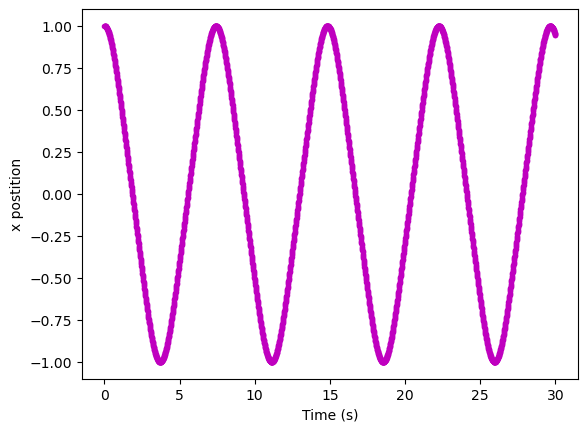

In [121]:
def f(r,t):

    x = r[0]
    v = r[1]

    #define the diff eqn

    fx = v
    fv = -omega**2 * x**3

    #return vector array of functions

    return np.array([fx,fv], float)

def RK4_multi(r,t_points,h,f):
    xpts = np.zeros(len(t_points))
    vpts = np.zeros(len(t_points))


    #adding what we made in class and adapting it


    for i in range(len(t_points)):
        xpts[i] = r[0]
        vpts[i] = r[1]

        k1 = h * f(r, t_points[i])
        k2 = h * f(r+0.5*k1, t_points[i]+0.5*h)
        k3 =  h * f(r+0.5*k2, t_points[i]+0.5*h)
        k4 =  h * f(r+k3, t_points[i]*h)

        r+= (k1+2*k2+2*k3+k4)/6

    return xpts, vpts

t_start = 0.0
t_end = 30.0
N_steps = 3000
h = (t_end-t_start)/N_steps
t_points = np.arange(t_start,t_end+h,h)
omega = 1.0
fx = 0.0
x = 1.0
r = np.array([1,0], float)
xpts = np.zeros(len(t_points))
vpts = np.zeros(len(t_points))

x_pos, v_pos = RK4_multi(r,t_points,h,f)

plt.plot(t_points, x_pos, ".m")
plt.xlabel("Time (s)")
plt.ylabel("x postition")
plt.show()



#### Step 2: Once again, vary the amplitude to see what happens when we increase the amplitude from $x=1$ to $x=2$ to $x=4$. Plot all three position vs. time graphs on the same graph (be sure to include a legend). What do you notice about an anharmonic oscillator as the amplitude increases? 

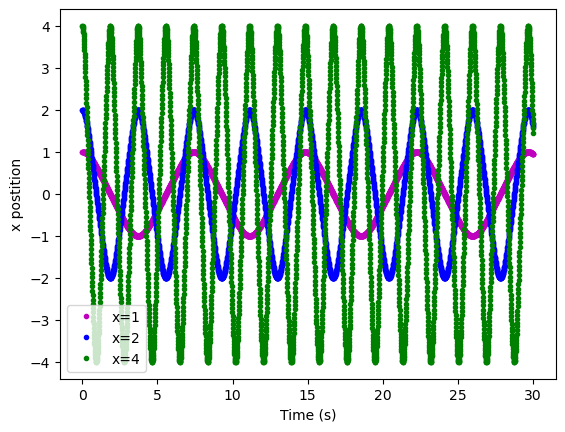

In [123]:
#changing the amplitude 

#for x = 1
r = np.array([1,0], float)
x_pos, v_pos = RK4_multi(r,t_points,h,f)
plt.plot(t_points, x_pos, ".m", label = "x=1")

#for x = 2
r = np.array([2,0], float)
x_pos, v_pos = RK4_multi(r,t_points,h,f)
plt.plot(t_points, x_pos, ".b", label = "x=2")

#for x = 4
r = np.array([4,0], float)
x_pos, v_pos = RK4_multi(r,t_points,h,f)
plt.plot(t_points, x_pos, ".g", label = "x=4")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("x postition")
plt.show()



For an anharmonic oscillator the period decreases when the amplitude increases! From the graph that was made this can be clearly seen although it is a little messy. 

#### Step 3: Now graph the *phase space* plot of the anharmonic oscillator. Include the phase space of the harmonic oscillator. In markdown, interpret the result and compare with the harmonic oscillator phase space plot. (Do this for the *original* initial conditions - they need to be the same to properly compare)

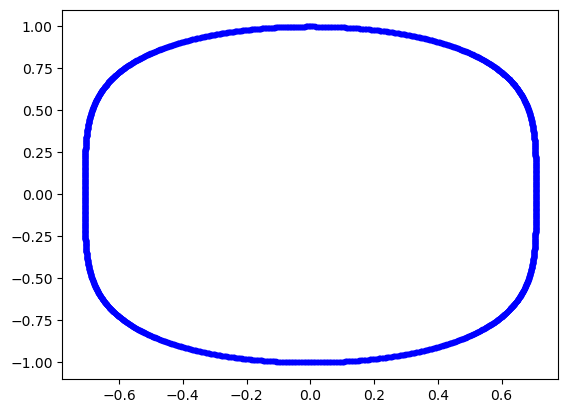

In [ ]:
#using the inital conditions and making the phase space plot
r = np.array([1,0], float)
x_pos, v_pos = RK4_multi(r,t_points,h,f)
plt.plot(v_pos,x_pos, ".b")
plt.show()

For this phase space plot the shape is not a nice elipse like the original. There are some vertical spots on the sides of the circle. This indicates some non linear behavior where we did not have that before. 